# RQ1 – Explainability / SHAP

Uses the provided cybersecurity intrusion dataset and explains which features influence `attack_detected`.

In [1]:
import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

OUTPUT_DIR = "responsible_ai_outputs"
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables_csv")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures_pdf")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

def find_file(possible_names):
    """Find uploaded dataset in current folder, /mnt/data, or Kaggle input folders."""
    search_roots = [".", "/mnt/data", "/kaggle/input"]
    for root in search_roots:
        if not os.path.exists(root):
            continue
        for name in possible_names:
            matches = glob.glob(os.path.join(root, "**", name), recursive=True)
            if matches:
                return matches[0]
    # Fallback: flexible contains search
    all_csvs = []
    for root in search_roots:
        if os.path.exists(root):
            all_csvs += glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)
    for f in all_csvs:
        base = os.path.basename(f).lower()
        for name in possible_names:
            token = name.replace("(1)", "").replace(".csv","").lower()
            if token in base:
                return f
    raise FileNotFoundError(f"Could not find any of: {possible_names}")

CYBER_FILE = find_file([
    "cybersecurity_intrusion_data(1).csv",
    "cybersecurity_intrusion_data.csv"
])
cyber = pd.read_csv(CYBER_FILE)

target_col = "attack_detected"
drop_cols = ["session_id"]
cyber = cyber.drop(columns=[c for c in drop_cols if c in cyber.columns])

X = cyber.drop(columns=[target_col])
y = cyber[target_col].astype(int)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="drop"
)

model = RandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred, zero_division=0),
    "recall": recall_score(y_test, pred, zero_division=0),
    "f1": f1_score(y_test, pred, zero_division=0),
}
print("Loaded:", CYBER_FILE)
print("Dataset shape:", cyber.shape)
print("Metrics:", metrics)

def save_bar(df, x, y, title, xlabel, ylabel, filename, rotation=30):
    plt.figure(figsize=(8, 4.8))
    plt.bar(df[x].astype(str), df[y])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)

Loaded: ./cybersecurity_intrusion_data.csv
Dataset shape: (9537, 10)
Metrics: {'accuracy': 0.8846960167714885, 'precision': 1.0, 'recall': 0.7420262664165104, 'f1': 0.8519116855142703}


Saved table: responsible_ai_outputs/tables_csv/RQ1_feature_importance.csv


,Feature,Importance
4,failed_logins,0.4143
1,login_attempts,0.2944
3,ip_reputation_score,0.2066
16,browser_type_Unknown,0.0367
2,session_duration,0.0195
0,network_packet_size,0.0125
5,unusual_time_access,0.0026
12,browser_type_Chrome,0.0023
13,browser_type_Edge,0.0017
9,encryption_used_AES,0.0016


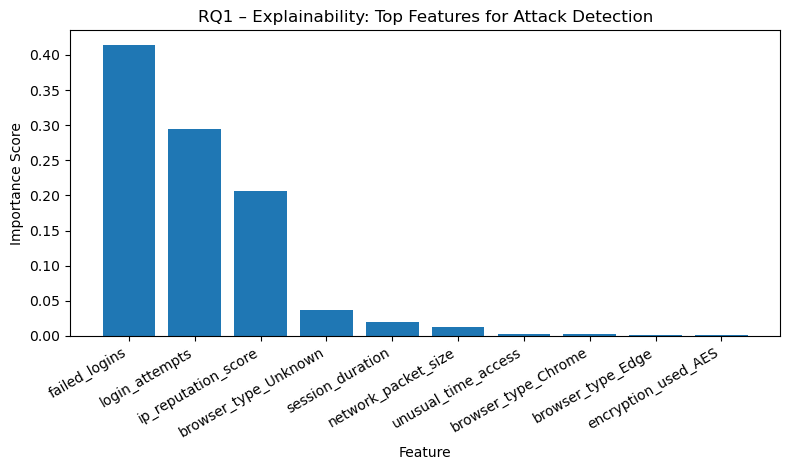

Saved figure: responsible_ai_outputs/figures_pdf/RQ1_feature_importance.pdf
SHAP not available or failed. Feature importance table is still saved.
Reason: No module named 'shap'


In [2]:
feature_names = clf.named_steps["preprocess"].get_feature_names_out()
rf = clf.named_steps["model"]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)


importance_df["Feature"] = (
    importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

top_importance = importance_df.head(10).copy()
top_importance["Importance"] = top_importance["Importance"].round(4)

csv_path = os.path.join(TABLE_DIR, "RQ1_feature_importance.csv")
top_importance.to_csv(csv_path, index=False)
print("Saved table:", csv_path)
display(top_importance)

save_bar(
    top_importance,
    x="Feature",
    y="Importance",
    title="RQ1 – Explainability: Top Features for Attack Detection",
    xlabel="Feature",
    ylabel="Importance Score",
    filename="RQ1_feature_importance.pdf"
)


try:
    import shap
    X_test_transformed = clf.named_steps["preprocess"].transform(X_test)
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test_transformed[:500])
    if isinstance(shap_values, list):
        values = np.abs(shap_values[1]).mean(axis=0)
    else:
        values = np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({"Feature": feature_names, "SHAP_Score": values})
    shap_df["Feature"] = shap_df["Feature"].str.replace("num__", "", regex=False).str.replace("cat__", "", regex=False)
    shap_df = shap_df.sort_values("SHAP_Score", ascending=False).head(10)
    shap_df["SHAP_Score"] = shap_df["SHAP_Score"].round(4)
    shap_csv = os.path.join(TABLE_DIR, "RQ1_SHAP_scores.csv")
    shap_df.to_csv(shap_csv, index=False)
    print("Saved optional SHAP table:", shap_csv)
    display(shap_df)
except Exception as e:
    print("SHAP not available or failed. Feature importance table is still saved.")
    print("Reason:", e)